In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [5]:
df = pd.read_csv('student_exam_scores.csv')

In [6]:
df.shape

(400, 3)

In [7]:
df.describe()

,Exam Score1,Exam Score2,Pass
count,400.000000,400.000000,400.000000
mean,49.812650,52.264925,0.280000
std,28.141381,29.348627,0.449561
min,0.240000,0.460000,0.000000
25%,24.010000,27.070000,0.000000
50%,50.735000,53.180000,0.000000
75%,75.442500,78.900000,1.000000
max,99.640000,99.990000,1.000000


In [8]:
df.isnull().sum()

Exam Score1    0
Exam Score2    0
Pass           0
dtype: int64

In [9]:
df.sample(10)

,Exam Score1,Exam Score2,Pass
372,97.13,89.79,1
238,84.38,55.06,1
96,44.68,40.46,0
293,45.96,16.44,0
24,45.32,59.09,0
264,63.67,65.03,1
250,31.88,84.74,0
365,79.72,73.31,1
46,52.62,18.13,0
112,19.63,27.47,0


In [10]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [12]:
regressor = LogisticRegression()

In [17]:
parameter = {'penalty':['l1','l2','elasticnet'],'C':[0.1,0.001,0.4,0.5,1,2,3,4,5,6,10,20,30,40,50,60],'max_iter':[100,200,300,400],'solver': ['saga'],'l1_ratio': [0.5]}

In [18]:
lcv = GridSearchCV(regressor,param_grid=parameter,scoring='accuracy',cv=5)

In [19]:
lcv.fit(x_train,y_train)

d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 0.001, ...], 'l1_ratio': [0.5], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [29]:
lcv.best_params_

{'C': 0.1,
 'l1_ratio': 0.5,
 'max_iter': 400,
 'penalty': 'elasticnet',
 'solver': 'saga'}

In [21]:
print(lcv.best_score_)

0.7833333333333333


In [22]:
y_pred = lcv.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score,classification_report,precision_score,log_loss

In [24]:
print(accuracy_score(y_test,y_pred))

0.85


In [25]:
precision_score(y_test,y_pred)

1.0

In [31]:
log_loss(y_test, lcv.predict_proba(x_test))

0.4891372790781079

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        77
           1       1.00      0.35      0.52        23

    accuracy                           0.85       100
   macro avg       0.92      0.67      0.71       100
weighted avg       0.87      0.85      0.82       100



In [28]:
print(np.bincount(y))

[288 112]


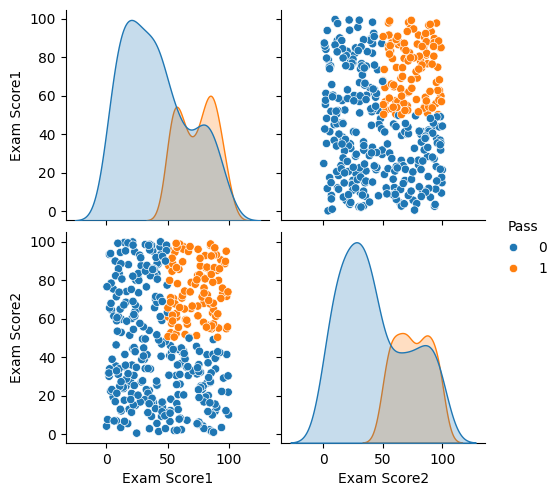

In [118]:
# EDA
sns.pairplot(df,hue='Pass')

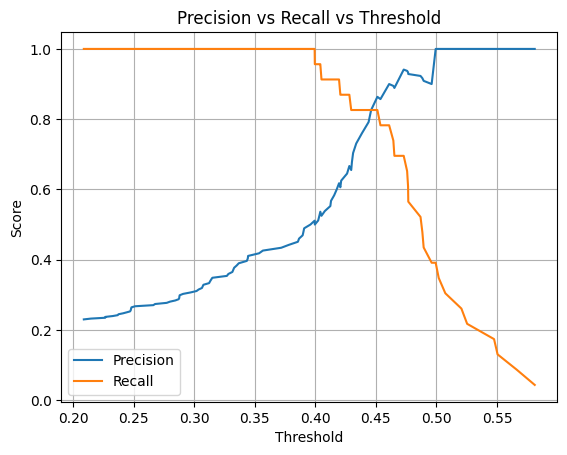

In [123]:
from sklearn.metrics import precision_recall_curve

probs = lcv.predict_proba(x_test)[:, 1]  # probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision vs Recall vs Threshold')
plt.grid()
plt.show()
